# Age-Gate Paradox — frozen-data analysis

This notebook is a finding-led readout of the frozen evidence. It uses the primary 600-record human evaluation sample, the refreshed network/topic artifacts, and the current exploratory H1-H4 result contracts. It validates those artifacts before displaying them. It does not repair or execute the blocked measurement lifecycle, PRIMARY-6, model selection, reserve activation, scraping, relabelling, automated full-corpus classification, or the final assessment report.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'data' / 'analysis' / 'fallback').exists():
    ROOT = ROOT.parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.analysis.fallback_analysis import check as check_fallback
from src.analysis.h1h3_human_sample import validate_h1h3_result
from src.analysis.h4_human_sample import validate_h4_result
FALLBACK = ROOT / 'data' / 'analysis' / 'fallback'
HUMAN_RESULT = ROOT / 'data' / 'analysis' / 'h1h3_human' / 'h1h3_result.json'
H4_RESULT = ROOT / 'data' / 'analysis' / 'h4_human' / 'h4_result.json'
validation = check_fallback()
human_results = validate_h1h3_result(HUMAN_RESULT)
h4_result = validate_h4_result(H4_RESULT)
manifest = json.loads((FALLBACK / 'analysis_manifest.json').read_text())
human = pd.read_csv(FALLBACK / 'human_sample_estimates.csv', keep_default_na=False)
hypotheses = pd.read_csv(FALLBACK / 'hypothesis_evidence.csv', keep_default_na=False)
cards = pd.read_csv(FALLBACK / 'finding_cards.csv', keep_default_na=False)
topics = pd.read_csv(FALLBACK / 'topic_name_candidates.csv', keep_default_na=False)
bertopic = pd.read_csv(ROOT / 'data' / 'analysis' / 'topics' / 'bertopic_sensitivity.csv', keep_default_na=False)
topic_manifest = json.loads((ROOT / 'data' / 'analysis' / 'topics' / 'topics_manifest.json').read_text())
figures = sorted((FALLBACK / 'figures').glob('*.png'))
assert validation['status'] == 'valid'
assert manifest['schema_version'] == 'age-gate-fallback.v3'
assert manifest['primary_evaluation_records'] == 600
assert manifest['eligible_records'] == 285
assert manifest['source_registry']['coverage'] == 'data/analysis/descriptive/coverage.csv'
assert topic_manifest['bertopic']['status'] == 'executed_multi_seed_sensitivity'
assert len(cards) == 5 and len(topics) == 18 and len(figures) <= 6
assert manifest['topic_summary']['interpretation_class_counts'] == {'artifact_or_contamination': 3, 'generic_or_discourse_style': 8, 'substantive': 7}
assert human_results['schema_version'] == 'h1h3-human-sample.v3'
assert human_results['H2']['weighting'] == 'unweighted'
assert 'fixed-quota selected-sample' in human_results['H2']['estimand']
assert h4_result['schema_version'] == 'h4-human-sample.v3'
display(pd.DataFrame([{
    'primary_records': manifest['primary_evaluation_records'],
    'eligible_records': manifest['eligible_records'],
    'bootstrap_replicates': manifest['bootstrap']['replicates'],
    'bootstrap_seed': manifest['bootstrap']['seed'],
    'figure_count': len(figures),
}]))

def show_figure(name):
    display(Image(filename=str(FALLBACK / 'figures' / name), width=900))

,primary_records,eligible_records,bootstrap_replicates,bootstrap_seed,figure_count
0,600,285,9999,20260915,5


## 1. Research problem and evidence boundaries

The study asks how age-assurance policy discourse differs across Australian legislation and implementation stages, and how platform structure, topics, and audiences shape the observable conversation. The fallback provides defensible descriptive and partial hypothesis evidence. It does not support causal claims, persuasion claims, or formal PRIMARY-6 confirmation.

## 2. Frozen corpus and human-sample coverage

The primary sample is the adjudicated evaluation file. Completion is derived from populated substantive fields; `annotation_status` is not used as the completion gate. Blank adjudicated frame labels are valid all-negative vectors when the other required fields are complete. Eligibility requires relevant, strict English, a single valid target, and non-empty author/cluster identifiers.

,measure,category,unweighted_n,status,notes
153,author_identifier_present,all,285,available,excluded_at_step=0; Required for author-level ...
154,cluster_identifier_present,all,285,available,excluded_at_step=0; Required for clustered unc...
155,primary_evaluation_records,all,600,available,excluded_at_step=0; Frozen coordinator evaluat...
156,relevant_policy_discourse,all,409,available,excluded_at_step=191; Codebook relevance is re...
157,required_adjudicated_fields_complete,all,600,available,excluded_at_step=0; All substantive fields pop...
158,single_valid_target_policy,all,285,available,excluded_at_step=120; Target is one of the thr...
159,strict_english,all,405,available,excluded_at_step=4; Primary estimates exclude ...


,measure,category,unweighted_n,notes
148,first_exclusion_reason,eligible,285,Mutually exclusive first failing eligibility r...
149,first_exclusion_reason,relevant_policy_discourse,191,Mutually exclusive first failing eligibility r...
150,first_exclusion_reason,single_valid_target_policy,120,Mutually exclusive first failing eligibility r...
151,first_exclusion_reason,strict_english,4,Mutually exclusive first failing eligibility r...
152,language_exclusion_breakdown,ambiguous_language,4,Among complete relevant rows; non_english=0.


,platform,scope,rows,strict_english_rows,unique_authors,unique_containers,human_calibrated_status
0,bluesky,E1,21516,14810,14882,2849,not_available_without_human_language_labels
1,bluesky,E2,43057,36912,24952,7311,not_available_without_human_language_labels
2,bluesky,E3,23031,21205,13570,3515,not_available_without_human_language_labels
3,bluesky,E4,32351,23263,22072,4693,not_available_without_human_language_labels
4,bluesky,E5,21000,19004,12612,3623,not_available_without_human_language_labels
5,reddit,AU_IMPLEMENTATION,45145,29599,17821,574,not_available_without_human_language_labels
6,reddit,AU_LEGISLATION,28175,18612,12039,424,not_available_without_human_language_labels
7,reddit,UK_ENFORCEMENT_CLUSTER,57983,38048,22730,766,not_available_without_human_language_labels
8,youtube,E1,2014,1076,1118,13,not_available_without_human_language_labels
9,youtube,E2,40497,22663,25930,50,not_available_without_human_language_labels


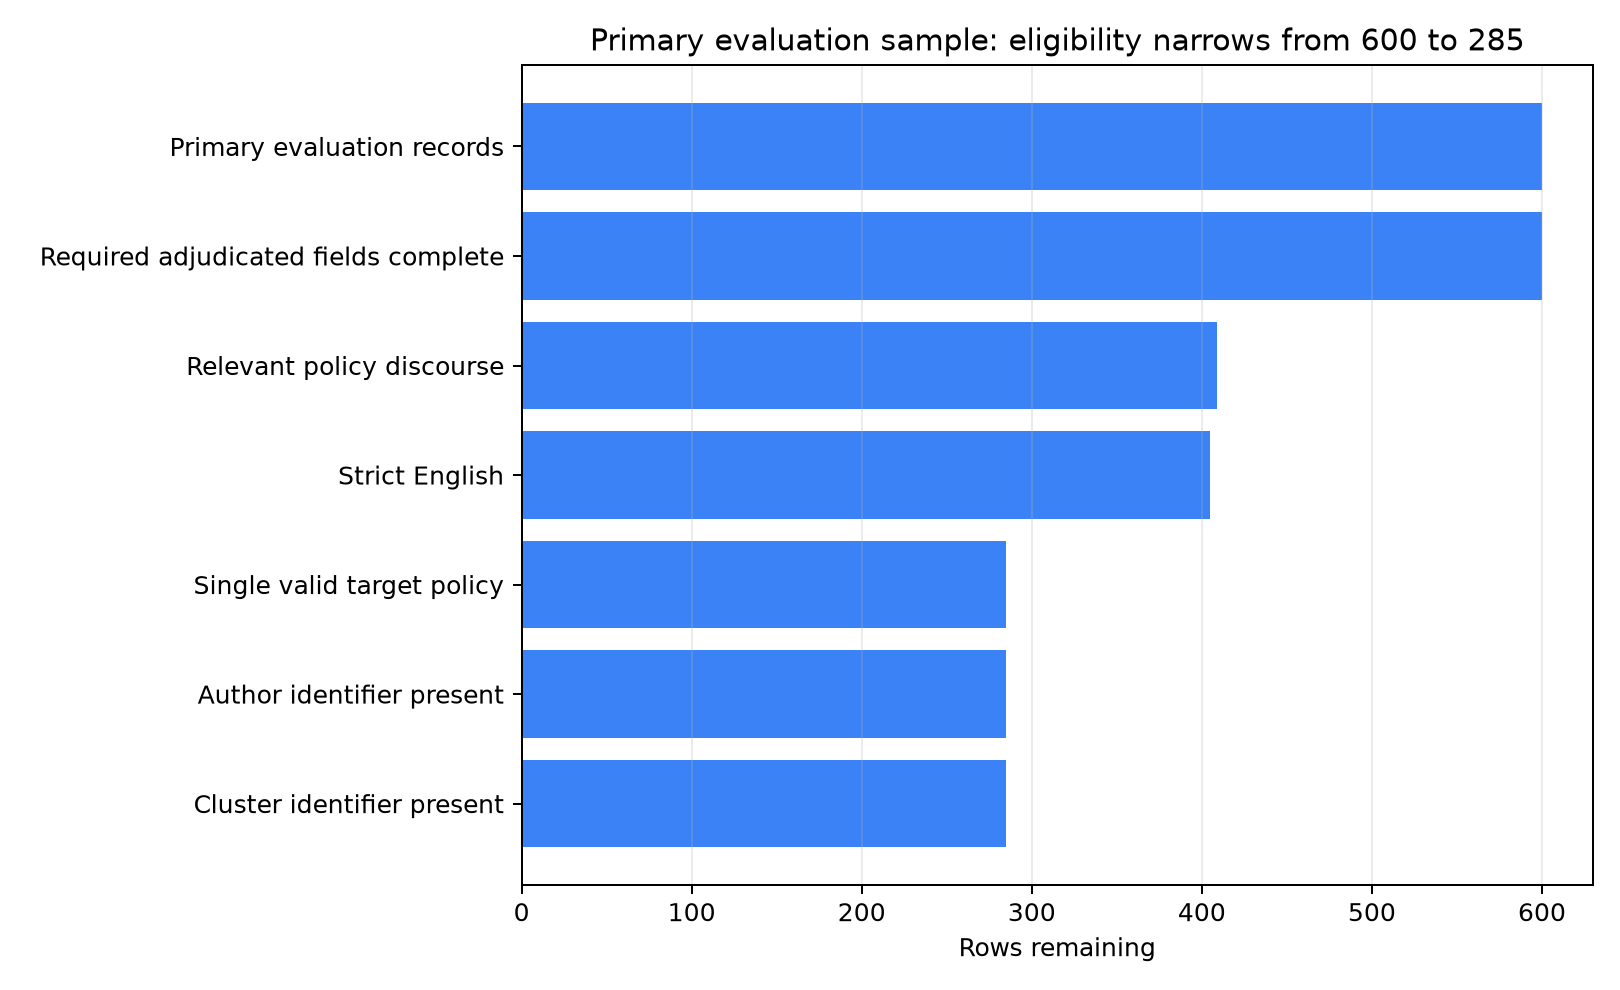

In [2]:
flow = human[human['analysis_type'].eq('eligibility_flow')].copy()
display(flow[['measure', 'category', 'unweighted_n', 'status', 'notes']])
display(human[human['analysis_type'].eq('eligibility_exclusion')][['measure', 'category', 'unweighted_n', 'notes']])
coverage = pd.read_csv(ROOT / 'data' / 'analysis' / 'descriptive' / 'coverage.csv')
display(coverage[['platform', 'scope', 'rows', 'strict_english_rows', 'unique_authors', 'unique_containers', 'human_calibrated_status']])
show_figure('sample_eligibility_flow.png')

## 3. Strongest discourse finding: weighted platform frame prevalence

The strongest directly observed discourse result is the weighted frame profile within each platform. Estimates use the eligible evaluation sample, normalized Hajek inverse-inclusion weights, and cluster-bootstrap intervals. Frames are non-exclusive and no direct between-platform contrast was estimated, so the result does not rank platforms or establish platform differences.

category,child_safety,circumvention_censorship_autonomy,governance_platform_responsibility,policy_assurance,privacy_surveillance
platform,,,,,
bluesky,0.305,0.395,0.315,0.990,0.122
reddit,0.201,0.733,0.500,0.910,0.191
youtube,0.569,0.491,0.393,0.622,0.142


,platform,category,estimate,lower_95,upper_95,unweighted_n,effective_sample_size
8,bluesky,child_safety,0.304768,0.1633139658193668,0.46568999123332344,94,38.55126399829852
9,bluesky,circumvention_censorship_autonomy,0.395357,0.25774013522042805,0.5491785676260462,94,38.55126399829852
10,bluesky,governance_platform_responsibility,0.315323,0.20356996196793972,0.4540171128131601,94,38.55126399829852
11,bluesky,policy_assurance,0.990471,0.9670095529488669,1.0,94,38.55126399829852
12,bluesky,privacy_surveillance,0.121885,0.06623334661495968,0.19650638307413892,94,38.55126399829852
50,reddit,child_safety,0.201261,0.014706400432230524,0.504363302897207,59,7.313049615040063
51,reddit,circumvention_censorship_autonomy,0.732799,0.389203719196191,0.903680906599051,59,7.313049615040063
52,reddit,governance_platform_responsibility,0.499519,0.045541475613912245,0.765788132667914,59,7.313049615040063
53,reddit,policy_assurance,0.909908,0.7128051374018194,0.9991688365384452,59,7.313049615040063
54,reddit,privacy_surveillance,0.191243,0.016307589893921236,0.4893315719408618,59,7.313049615040063


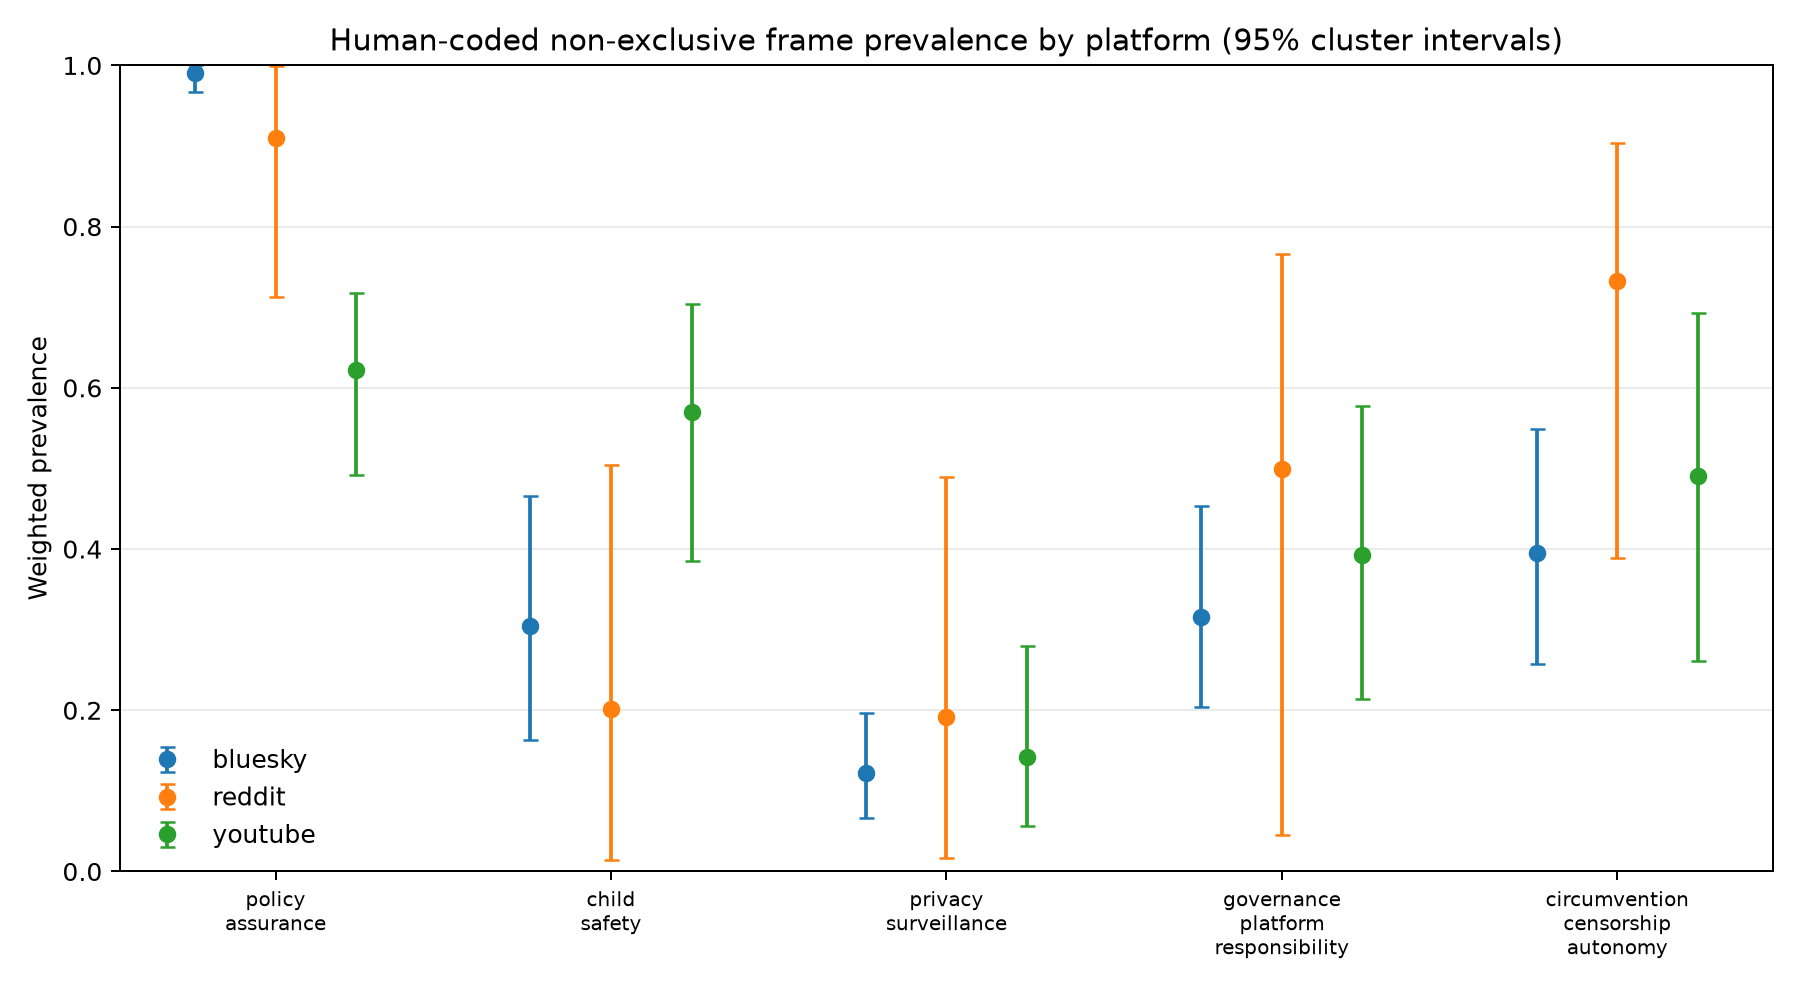

In [3]:
frame = human[(human['analysis_type'].eq('distribution')) & (human['measure'].eq('frame_prevalence')) & (human['case_window_id'].eq('ALL_CASES'))].copy()
frame['estimate'] = pd.to_numeric(frame['estimate'], errors='coerce')
frame_summary = frame.pivot(index='platform', columns='category', values='estimate').round(3)
display(frame_summary)
display(frame[['platform', 'category', 'estimate', 'lower_95', 'upper_95', 'unweighted_n', 'effective_sample_size']].sort_values(['platform', 'category']))
show_figure('weighted_frame_prevalence.png')

### Reliability and frame coverage

Coder A/B agreement is reported separately for the development, evaluation, and reserve splits before adjudication. The development row is development reliability; the reserve row is a separate reserve-sensitivity check, not model-selection evidence. Frame blanks are treated as no supported frame for agreement calculations. Exact-set frame agreement is 0.618 in development, 0.472 in evaluation, and 0.440 in reserve; evaluation and reserve also contain per-frame failures against the plan's 0.80 agreement/0.60 kappa thresholds. Automated frame inference therefore remains blocked, and every prevalence result below relies on adjudicated human labels.

In [4]:
reliability = human[human['analysis_type'].eq('reliability')]
display(reliability[reliability['platform'].eq('all')][['split', 'case_window_id', 'measure', 'category', 'statistic', 'estimate', 'unweighted_n']].sort_values(['split', 'measure', 'category', 'statistic']))

,split,case_window_id,measure,category,statistic,estimate,unweighted_n
179,development,ALL_DEVELOPMENT,frame_labels,all,cohen_kappa,0.7686903213226663,600
180,development,ALL_DEVELOPMENT,frame_labels,all,mean_multilabel_jaccard,0.7984444444444444,600
178,development,ALL_DEVELOPMENT,frame_labels,all,percent_agreement,0.6183333333333333,600
182,development,ALL_DEVELOPMENT,frame_labels,child_safety,cohen_kappa,0.7917252095145214,600
181,development,ALL_DEVELOPMENT,frame_labels,child_safety,percent_agreement,0.93,600
...,...,...,...,...,...,...,...
241,reserve,ALL_RESERVE,sentiment,all,percent_agreement,0.7766666666666666,300
244,reserve,ALL_RESERVE,stance,all,cohen_kappa,0.5597163646475414,300
243,reserve,ALL_RESERVE,stance,all,percent_agreement,0.6833333333333333,300
246,reserve,ALL_RESERVE,target_policy,all,cohen_kappa,0.8548489521908736,300


## 4. Strongest community/network finding

The report-facing topology result is restricted to the frozen Bluesky actor-attention graph, whose registry status is `candidate_network_ready`. Edges are directed from replier to replied-to author and weighted by observed reply multiplicity. The graph is built from phrase-exact roots and observed descendants; invalid endpoints, self-loops, and non-exact hits are excluded. PageRank is received attention/structural prestige, not persuasion or causal influence.

,graph_id,scope,nodes,edges,weighted_edge_total,directed,communities,community_modularity,null_median_modularity,observed_minus_null_modularity,community_median_ari
0,B_ACTOR_ATTENTION,E2,7886,8632,9767.0,True,343,0.880591,0.547576,0.333015,0.830099
1,B_ACTOR_ATTENTION,E3,3700,3812,4235.0,True,203,0.919936,0.314882,0.605053,0.805033


,graph_id,scope,rank_correlation,top_k_jaccard,replicates,nodes,edges,weighted_edge_total
0,B_ACTOR_ATTENTION,E2,0.994974,0.818182,5,7886,8632,9767.0
1,B_ACTOR_ATTENTION,E2,0.994249,0.769912,5,7886,8632,9767.0
2,B_ACTOR_ATTENTION,E2,0.997460,0.785714,5,7886,8632,9767.0
3,B_ACTOR_ATTENTION,E2,0.995562,0.754386,5,7886,8632,9767.0
4,B_ACTOR_ATTENTION,E2,0.996052,0.769912,5,7886,8632,9767.0
5,B_ACTOR_ATTENTION,E3,0.999017,0.739130,5,3700,3812,4235.0
6,B_ACTOR_ATTENTION,E3,0.998431,0.769912,5,3700,3812,4235.0
7,B_ACTOR_ATTENTION,E3,0.997708,0.724138,5,3700,3812,4235.0
8,B_ACTOR_ATTENTION,E3,0.997743,0.754386,5,3700,3812,4235.0
9,B_ACTOR_ATTENTION,E3,0.998664,0.739130,5,3700,3812,4235.0


,betweenness_method,betweenness_top_decile_jaccard,directed,edges,graph_id,nodes,participation_median,participation_nonzero_share,participation_p90,scope,weighted_edge_total
0,igraph_exact,1.0,True,8632,B_ACTOR_ATTENTION,7886,0.0,0.098149,0.0,E2,9767.0
1,igraph_exact,1.0,True,3812,B_ACTOR_ATTENTION,3700,0.0,0.064054,0.0,E3,4235.0


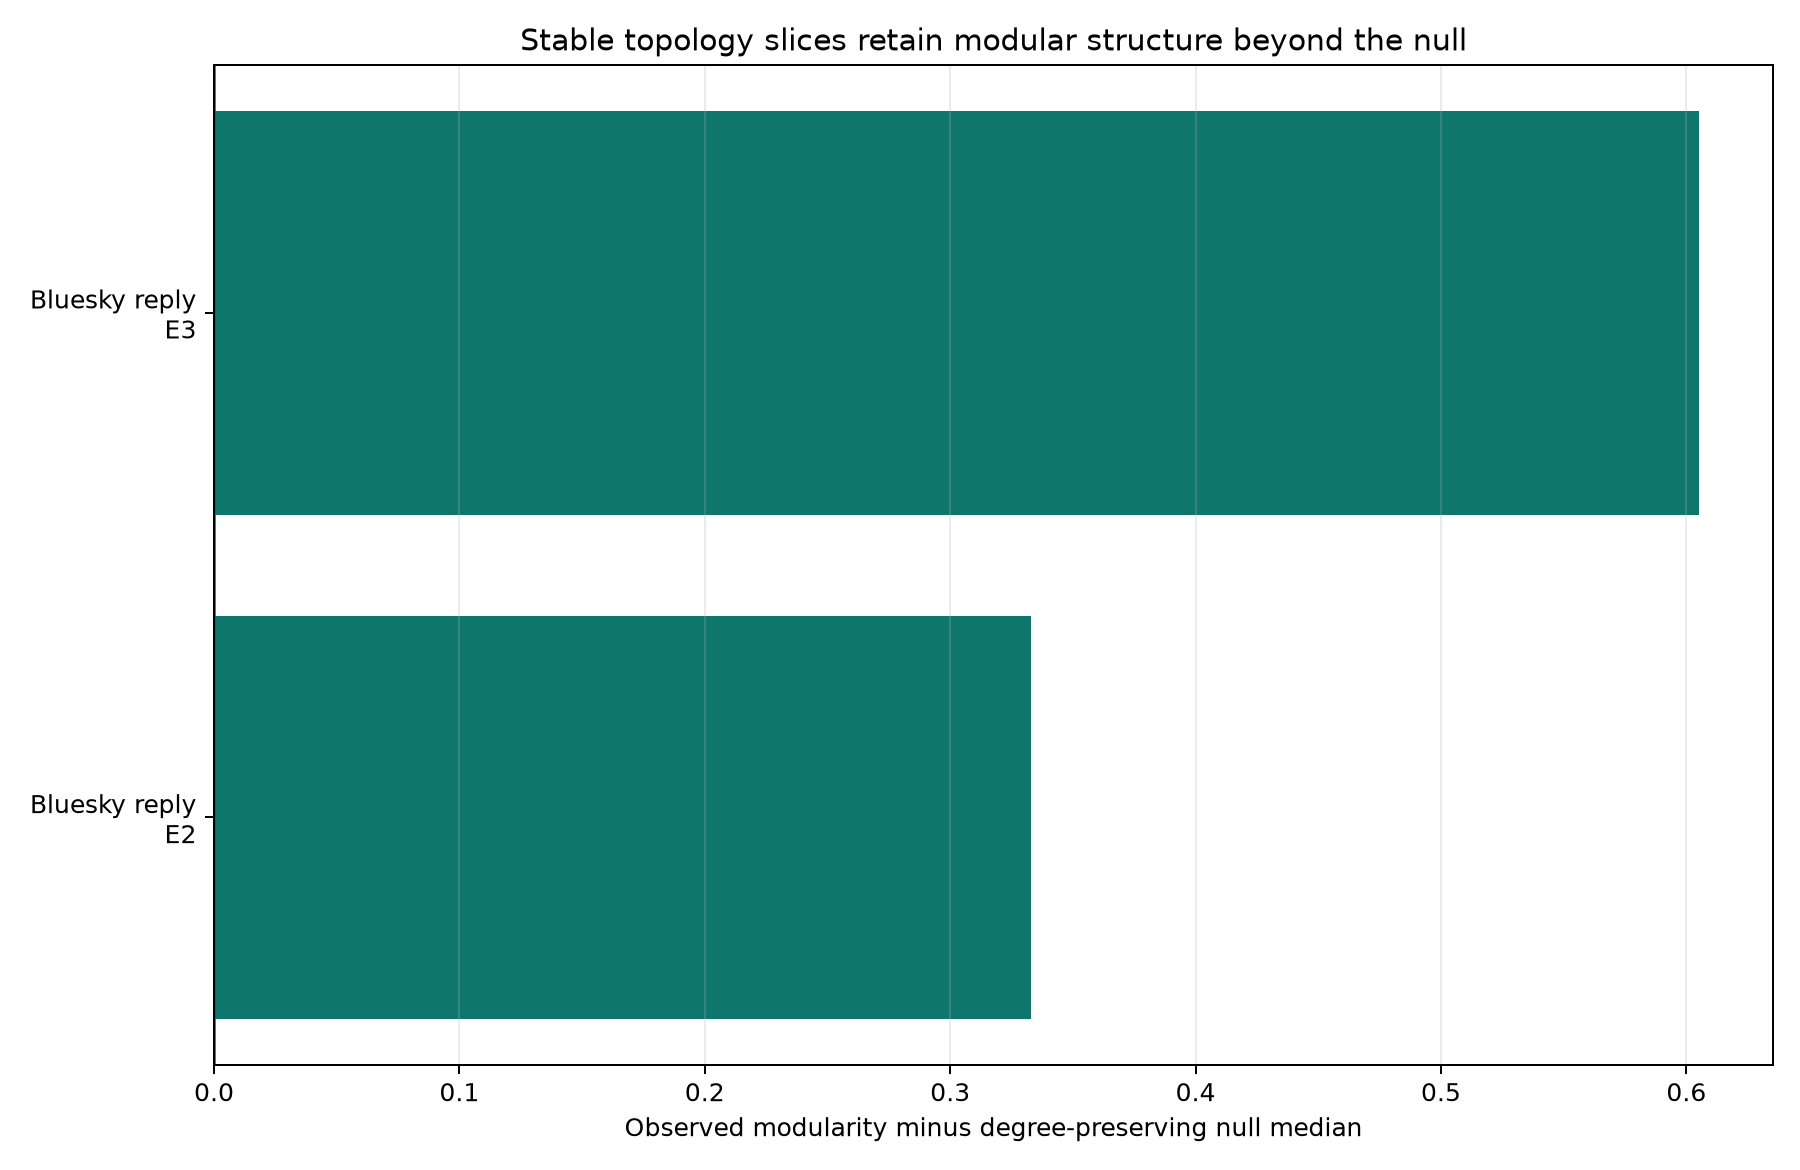

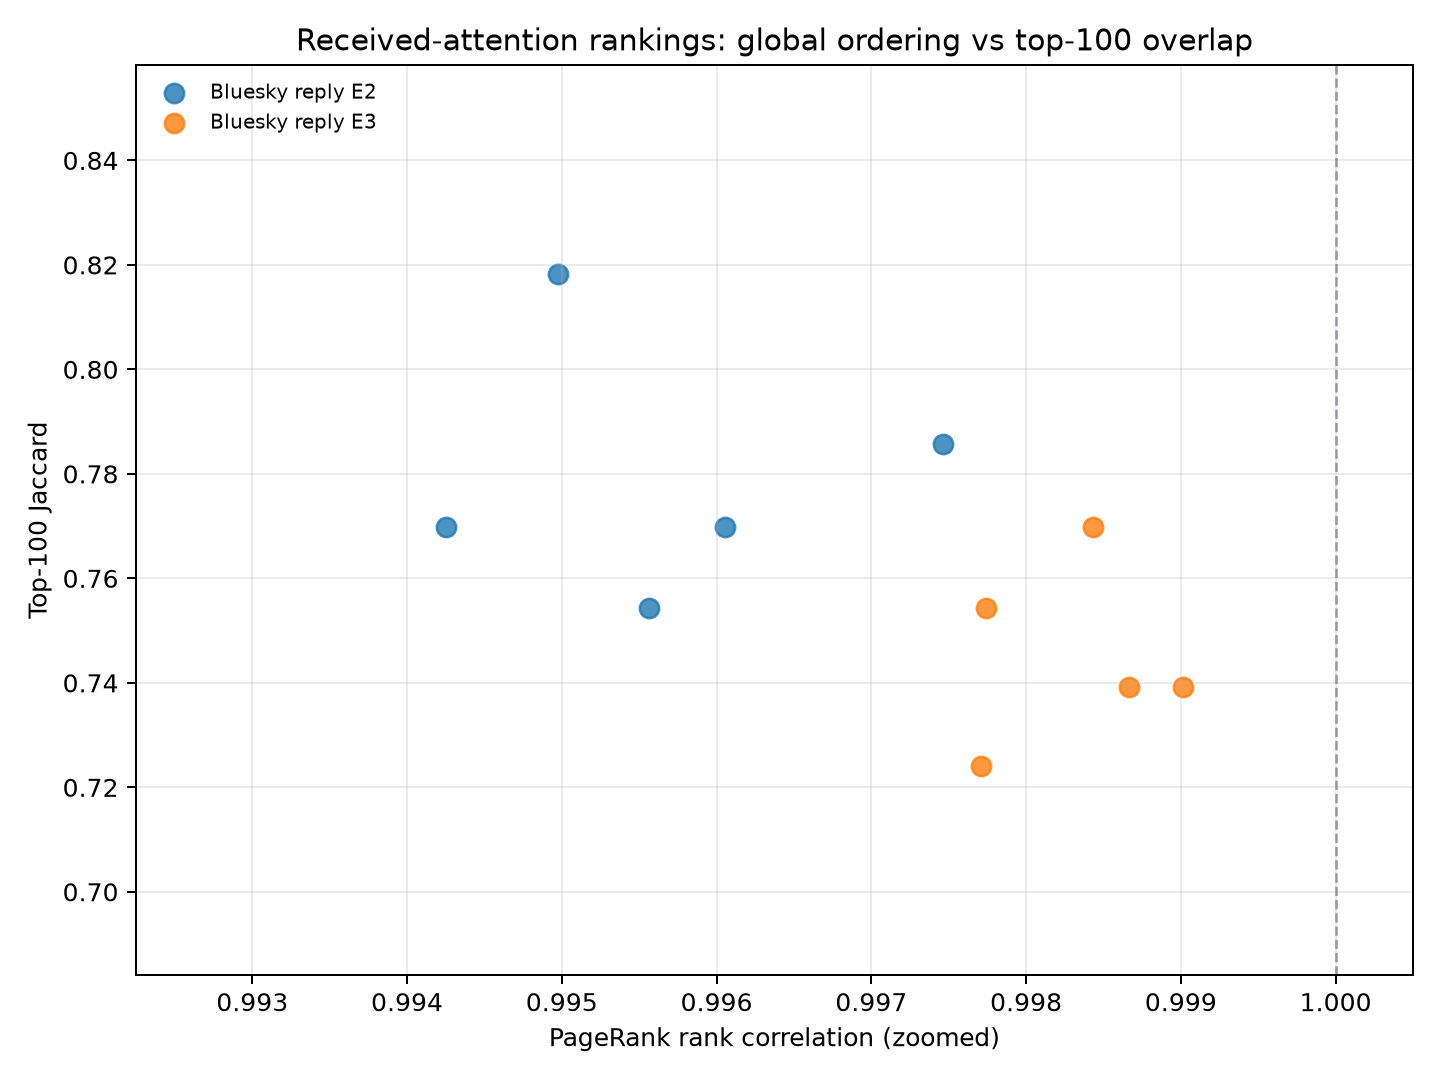

In [5]:
structure = pd.read_csv(ROOT / 'data' / 'analysis' / 'networks' / 'structure' / 'structure_summary.csv')
bluesky_structure = structure[structure['graph_id'].eq('B_ACTOR_ATTENTION')][['graph_id', 'scope', 'nodes', 'edges', 'weighted_edge_total', 'directed', 'communities', 'community_modularity', 'null_median_modularity', 'observed_minus_null_modularity', 'community_median_ari']]
display(bluesky_structure)
pagerank = pd.read_csv(ROOT / 'data' / 'analysis' / 'networks' / 'structure' / 'pagerank_stability.csv')
pagerank_view = pagerank[(pagerank['graph_id'].eq('B_ACTOR_ATTENTION')) & (pagerank['status'].eq('edge_bootstrap'))][['graph_id', 'scope', 'rank_correlation', 'top_k_jaccard', 'replicates']].merge(bluesky_structure[['scope', 'nodes', 'edges', 'weighted_edge_total']], on='scope', how='left')
display(pagerank_view)
display(pd.DataFrame(manifest['network']['role_summary']))
show_figure('community_null_comparison.png')
show_figure('pagerank_stability.png')

## 5. Topic and cascade evidence

NMF is the main topic result. All 18 components were reviewed using top terms, prevalence and three masked representative documents each. Only seven were substantively interpretable; eight primarily captured generic language or discourse style, and three reflected link-only, removed-content or off-topic artifacts. Stability therefore did not guarantee semantic validity. Across three seeds, BERTopic produced hundreds of small components per run with only moderate cross-seed stability, so it is retained as fragmentation sensitivity rather than one-to-one confirmation of NMF. Existing cascade summaries are shown only for the Bluesky candidate-ready observed-parent-edge artifact.

,platform,topic_id,candidate_name,interpretation_class,mean_seed_stability,mean_share,scope_share_min,scope_share_max,scope_share_sd,min_scope_documents,masked_review_examples,status
0,bluesky,0,Broad age-verification conversation,generic_or_discourse_style,1.000000,0.696583,0.627586,0.765581,0.097577,14078,3,team-authorized_agent-assisted_review
1,bluesky,1,Australian policy link-only posts,artifact_or_contamination,1.000000,0.051741,0.042319,0.061163,0.013325,1372,3,team-authorized_agent-assisted_review
2,bluesky,2,Australian under-16 social-media ban,substantive,1.000000,0.140788,0.038754,0.242823,0.144299,1511,3,team-authorized_agent-assisted_review
3,bluesky,3,UK Online Safety Act and repeal debate,substantive,1.000000,0.068430,0.022958,0.113901,0.064306,515,3,team-authorized_agent-assisted_review
4,bluesky,4,Templated GB News/Ofcom petition spillover,artifact_or_contamination,1.000000,0.026459,0.010567,0.042350,0.022474,412,3,team-authorized_agent-assisted_review
5,bluesky,5,UK parliamentary petition mobilisation,substantive,1.000000,0.016000,0.003121,0.028879,0.018214,70,3,team-authorized_agent-assisted_review
6,reddit,0,General long-form policy discussion,generic_or_discourse_style,0.933007,0.705625,0.681647,0.730183,0.024273,17875,3,team-authorized_agent-assisted_review
7,reddit,1,Second-person address and interpersonal reactions,generic_or_discourse_style,0.933007,0.078427,0.075510,0.082107,0.003364,1969,3,team-authorized_agent-assisted_review
8,reddit,2,Social-media-ban posts with removed-content ar...,artifact_or_contamination,0.933007,0.052376,0.018251,0.071509,0.029626,947,3,team-authorized_agent-assisted_review
9,reddit,3,Short demonstrative and evaluative reactions,generic_or_discourse_style,0.933007,0.054761,0.051789,0.059456,0.004114,1313,3,team-authorized_agent-assisted_review


,platform,seed,components,median_documents,mean_seed_stability
0,bluesky,17,606,26.0,0.625279
1,bluesky,29,611,25.0,0.625279
2,bluesky,41,588,25.0,0.625279
3,reddit,17,748,25.0,0.543049
4,reddit,29,754,25.0,0.543049
5,reddit,41,753,25.0,0.543049
6,youtube,17,175,39.0,0.592205
7,youtube,29,141,43.0,0.592205
8,youtube,41,137,41.0,0.592205


,platform,scope,cascades,median_depth,median_breadth,p90_breadth,median_structural_virality
0,bluesky,E2,1125,1.0,4.0,16.0,1.600000
1,bluesky,E3,534,1.0,5.0,15.0,1.666667


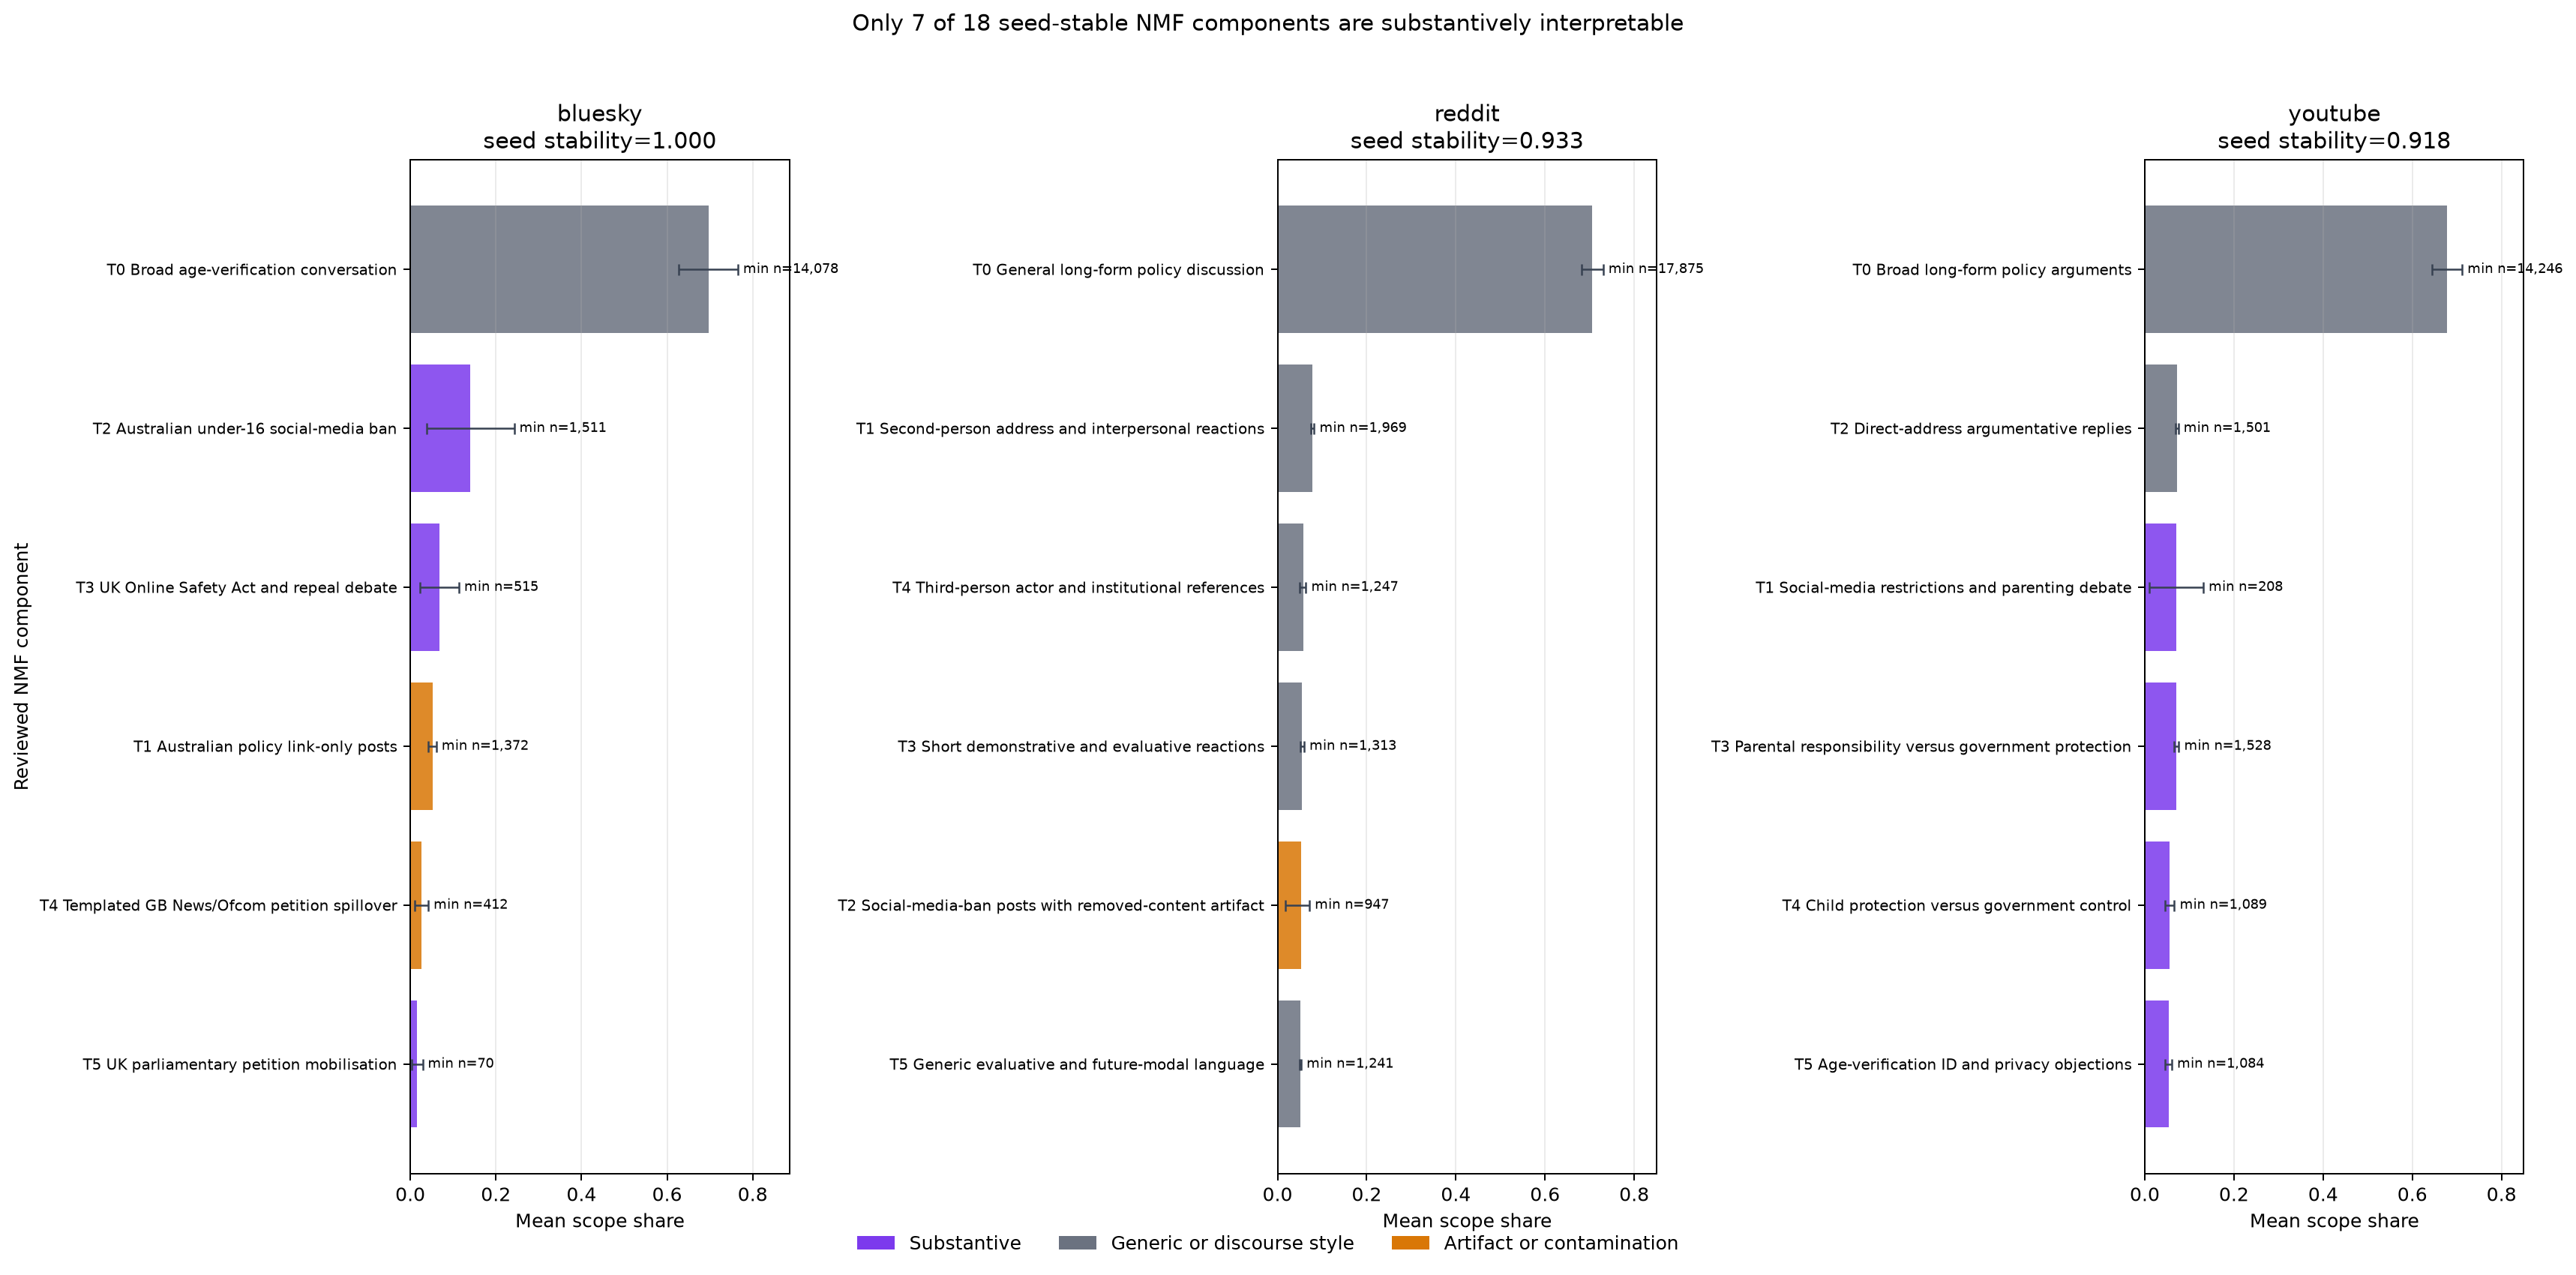

In [6]:
display(topics[['platform', 'topic_id', 'candidate_name', 'interpretation_class', 'mean_seed_stability', 'mean_share', 'scope_share_min', 'scope_share_max', 'scope_share_sd', 'min_scope_documents', 'masked_review_examples', 'status']])
bertopic_runs = bertopic.groupby(['platform', 'seed'], as_index=False).agg(components=('topic_id', 'nunique'), median_documents=('documents', 'median'), mean_seed_stability=('mean_seed_stability', 'first'))
display(bertopic_runs)
cascade = pd.read_csv(ROOT / 'data' / 'analysis' / 'networks' / 'temporal' / 'cascade_summary.csv')
cascade_view = cascade[(cascade['platform'].eq('bluesky')) & (cascade['observed_parent_edges']) & (cascade['validity_status'].eq('candidate_network_ready'))]
cascade_view = cascade_view.groupby(['platform', 'scope'], as_index=False).agg(cascades=('container_id', 'size'), median_depth=('max_depth', 'median'), median_breadth=('max_breadth', 'median'), p90_breadth=('max_breadth', lambda value: value.quantile(.90)), median_structural_virality=('structural_virality', 'median'))
display(cascade_view)
show_figure('topic_prevalence_stability.png')

## 6. Current exploratory H1-H4 results

The refreshed exploratory artifact has five estimable endpoints. H1-B is directional but below its planned effect margin; H1-R, both H2 comparisons and H4 are inconclusive; planned H3 is not estimable and remains represented only by its relaxed one-document sensitivity. H2 is explicitly an unweighted fixed-quota selected-sample comparison: its results are not population estimates or stage shares. These results are separate from the fallback's unavailable confirmatory endpoints.

In [7]:
display(hypotheses[['endpoint', 'status', 'estimate', 'interval', 'evidence_available', 'report_safe_wording']])
h2 = human_results['H2']
display(pd.DataFrame([
    {'endpoint': endpoint, 'status': result['status'], 'weighting': result.get('weighting'),
     'observed': result.get('observed'), 'lower_95': result.get('lower_95'),
     'upper_95': result.get('upper_95'), 'holm_p': result.get('holm_adjusted_p_value')}
    for endpoint, result in h2['endpoints'].items()
]))
print(h2['estimand'])
display(human[human['analysis_type'].eq('h4_audience_profile')][['platform', 'case_window_id', 'category', 'estimate', 'unweighted_n', 'effective_sample_size']])
display(cards[['finding_id', 'claim', 'evidential_status', 'stakeholder_implication', 'measurable_indicator_of_success', 'reconsideration_trigger']])

,endpoint,status,estimate,interval,evidence_available,report_safe_wording
0,H1-R,unavailable,,not estimated,joined_labelled_rows=43; adequate_communities=...,The pre-specified H1 test is unavailable becau...
1,H1-B,unavailable,,not estimated,joined_labelled_rows=33; adequate_communities=...,The pre-specified H1 test is unavailable becau...
2,H2-P,unavailable,,not estimated,target_policy=AU_SOCIAL_MINIMUM_AGE; legislati...,After restricting the comparison to AU_SOCIAL_...
3,H2-C,unavailable,,not estimated,target_policy=AU_SOCIAL_MINIMUM_AGE; legislati...,After restricting the comparison to AU_SOCIAL_...
4,H3,unavailable,,not estimated,joined_labelled_rows=43; unique_authors=43; br...,Frozen roles can be joined to a small labelled...
5,H4,unavailable,,not estimated,selected_video_source_type_audience_profiles=1...,Selected-video audience frame profiles differ ...


,endpoint,status,weighting,observed,lower_95,upper_95,holm_p
0,H2-C,estimated,unweighted,0.005556,-0.202718,0.215280,0.9598
1,H2-P,estimated,unweighted,0.066667,-0.133333,0.267087,0.7566


unweighted exploratory fixed-quota selected-sample comparison within the sampled Reddit documents; not a population or stage-share estimate


,platform,case_window_id,category,estimate,unweighted_n,effective_sample_size
163,youtube,E2_E3,commentary:child_safety,0.5602018116233506,58,17.452796027760996
164,youtube,E2_E3,commentary:circumvention_censorship_autonomy,0.3795110293942668,58,17.452796027760996
165,youtube,E2_E3,commentary:governance_platform_responsibility,0.44940159746411545,58,17.452796027760996
166,youtube,E2_E3,commentary:policy_assurance,0.5782224233258786,58,17.452796027760996
167,youtube,E2_E3,commentary:privacy_surveillance,0.1759064260470345,58,17.452796027760996
168,youtube,E2_E3,news:child_safety,0.6099538728835887,61,13.639161508209863
169,youtube,E2_E3,news:circumvention_censorship_autonomy,0.5846296178692083,61,13.639161508209863
170,youtube,E2_E3,news:governance_platform_responsibility,0.35048775034739627,61,13.639161508209863
171,youtube,E2_E3,news:policy_assurance,0.6847858721959605,61,13.639161508209863
172,youtube,E2_E3,news:privacy_surveillance,0.08226586649280372,61,13.639161508209863


,finding_id,claim,evidential_status,stakeholder_implication,measurable_indicator_of_success,reconsideration_trigger
0,F1,Within-platform human-coded estimates show pol...,descriptive_human_sample,Use the observed profiles to pre-register plat...,Each pilot reports its platform-specific denom...,If direct pilot contrasts do not reproduce the...
1,F2,The strongest frozen topology slice shows comm...,directly_observed_topology,Platform trust-and-safety and public-interest ...,"A pilot reports comprehension, unresolved priv...",If one community shows materially higher priva...
2,F3,Bluesky received-attention rankings are stable...,directly_observed_topology,Platform research and communications leads sho...,An independent review finds that every public ...,If rankings become unstable under the recorded...
3,F4,Seed stability did not guarantee semantic vali...,exploratory_partial,Policy and communications analysts should use ...,Every topic claim in the report maps to a subs...,If an independent analyst cannot reproduce a s...
4,F5,Selected YouTube audiences show source-type-sp...,descriptive_partial,Platform education and policy teams should fir...,"A source-type pilot tracks comprehension, priv...",If a source type produces a material rise in p...


## 7. Triangulation, limitations, and prioritised actions

Across evidence layers, the defensible story is descriptive and structural rather than causal: within-platform frame profiles provide the clearest observed discourse evidence, while the frozen Bluesky reply graph is modular and its received-attention ranking is stable. Topic review adds a methodological finding: only seven of 18 seed-stable components were substantively interpretable. The exploratory artifact now provides a directional but sub-threshold H1-B result, inconclusive H1-R/H2/H4 comparisons, and a non-estimable planned H3. H2 remains explicitly unweighted and selected-sample only; none of these results supports a population-stage claim or confirmatory PRIMARY-6 conclusion.

Prioritised actions:

1. Platform trust-and-safety and communications teams should use the observed within-platform frame profiles to pre-register platform-specific message-pilot hypotheses, without assuming that the platforms differ. Success: pilots report denominators, direct contrasts, comprehension, unresolved privacy/safety questions, and circumvention confusion. Reconsider if the direct contrasts do not reproduce the descriptive profile or a variant raises rights-risk complaints: withdraw the tailoring claim and use a common safeguarded explanation.
2. Platform trust-and-safety teams should use the structurally distinct community and source-type evidence to design community-aware explanations without targeting individuals from centrality scores. Success: pilots report reach, comprehension, and rights-risk indicators by community/source with denominators. Reconsider if any segment shows materially higher rights-risk complaints or misunderstanding: withdraw that message variant and commission a rights review.

In [8]:
print('Exploratory endpoint statuses:')
display(pd.DataFrame([
    {'endpoint': endpoint, 'status': result.get('status'), 'meets_planned_rule': result.get('meets_planned_effect_and_p')}
    for endpoint, result in {**human_results['H1'], **human_results['H2']['endpoints'], 'H3': human_results['H3'], 'H4': {'status': h4_result['status'], 'meets_planned_rule': h4_result['meets_nominal_rule']}}.items()
]))
print('Fallback unavailable or not claimed:')
display(hypotheses[hypotheses['status'].eq('unavailable')][['endpoint', 'exact_limitation']])
print('Report-facing figures:')
display(pd.DataFrame({'figure': [path.name for path in figures]}))

Exploratory endpoint statuses:


,endpoint,status,meets_planned_rule
0,H1-B,estimated,False
1,H1-R,estimated,False
2,H2-C,estimated,False
3,H2-P,estimated,False
4,H3,not_estimable,None
5,H4,estimated,None


Fallback unavailable or not claimed:


,endpoint,exact_limitation
0,H1-R,Only sparse primary evaluation labels joined t...
1,H1-B,Only sparse primary evaluation labels joined t...
2,H2-P,Target-restricted H2 is unavailable: AU_SOCIAL...
3,H2-C,Target-restricted H2 is unavailable: AU_SOCIAL...
4,H3,the planned per-author frame-diversity estiman...
5,H4,the existing YouTube metadata audit is absent ...


Report-facing figures:


,figure
0,community_null_comparison.png
1,pagerank_stability.png
2,sample_eligibility_flow.png
3,topic_prevalence_stability.png
4,weighted_frame_prevalence.png
